In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet152
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0
GPU Available: []


In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth configured successfully!")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("No GPU detected. Training will use CPU.")

BASE_PATH = os.path.join(os.path.expanduser('~'), 'Desktop', 'BrainTumorProject', 'archive')
TRAIN_DIR = os.path.join(BASE_PATH, 'Training')
TEST_DIR = os.path.join(BASE_PATH, 'Testing')

print(f"Training data: {TRAIN_DIR}")
print(f"Testing data: {TEST_DIR}")
print(f"Training folder exists: {os.path.exists(TRAIN_DIR)}")
print(f"Testing folder exists: {os.path.exists(TEST_DIR)}")

No GPU detected. Training will use CPU.
Training data: C:\Users\Akash\Desktop\BrainTumorProject\archive\Training
Testing data: C:\Users\Akash\Desktop\BrainTumorProject\archive\Testing
Training folder exists: True
Testing folder exists: True


In [4]:
if os.path.exists(TRAIN_DIR):
    classes = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
    classes.sort()
    print(f"Detected classes: {classes}")
    print(f"Number of classes: {len(classes)}")
    
    print("\n--- Training Data Distribution ---")
    for class_name in classes:
        class_path = os.path.join(TRAIN_DIR, class_name)
        img_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"{class_name}: {img_count} images")
    
    print("\n--- Testing Data Distribution ---")
    for class_name in classes:
        class_path = os.path.join(TEST_DIR, class_name)
        if os.path.exists(class_path):
            img_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            print(f"{class_name}: {img_count} images")

Detected classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4

--- Training Data Distribution ---
glioma: 1321 images
meningioma: 1339 images
notumor: 1595 images
pituitary: 1457 images

--- Testing Data Distribution ---
glioma: 300 images
meningioma: 306 images
notumor: 405 images
pituitary: 300 images


In [5]:
IMG_SIZE = (224, 224)
NUM_CLASSES = len(classes)
BATCH_SIZE = 16
EPOCHS = 40
LEARNING_RATE = 0.0001

print("=== ResNet152 Training Configuration ===")
print(f"Image size: {IMG_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

=== ResNet152 Training Configuration ===
Image size: (224, 224)
Number of classes: 4
Batch size: 16
Epochs: 40
Learning rate: 0.0001


In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print("Data generators created!")
print(f"Training batches per epoch: {train_generator.samples // BATCH_SIZE}")
print(f"Validation batches: {val_generator.samples // BATCH_SIZE}")
print(f"Class indices: {train_generator.class_indices}")

Found 5712 images belonging to 4 classes.
Found 1312 images belonging to 4 classes.
Data generators created!
Training batches per epoch: 357
Validation batches: 82
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [7]:
def build_resnet152_model(img_size, num_classes):
    base_model = ResNet152(
        weights='imagenet',
        include_top=False,
        input_shape=(*img_size, 3)
    )
    
    base_model.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D(name='avg_pool')(x)
    x = Dense(512, activation='relu', name='fc1')(x)
    x = Dropout(0.5, name='dropout1')(x)
    x = Dense(256, activation='relu', name='fc2')(x)
    x = Dropout(0.3, name='dropout2')(x)
    predictions = Dense(num_classes, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions, name='ResNet152_BrainTumor')
    
    return model

print("Building ResNet152 model...")
model = build_resnet152_model(IMG_SIZE, NUM_CLASSES)

print("\n=== RESNET152 ARCHITECTURE ===")
model.summary()

print(f"\nTotal parameters: {model.count_params():,}")
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {model.count_params() - trainable_params:,}")

Building ResNet152 model...

=== RESNET152 ARCHITECTURE ===


Model: "ResNet152_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 59,552,388 (227.17 MB)

 Trainable params: 1,181,444 (4.51 MB)

 Non-trainable params: 58,370,944 (222.67 MB)


Total parameters: 59,552,388
Trainable parameters: 1,181,444
Non-trainable parameters: 58,370,944


In [8]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("ResNet152 compiled successfully!")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss function: categorical_crossentropy")
print(f"Metrics: accuracy, precision, recall")

ResNet152 compiled successfully!
Optimizer: Adam (lr=0.0001)
Loss function: categorical_crossentropy
Metrics: accuracy, precision, recall


In [9]:
os.makedirs('models', exist_ok=True)

callbacks = [
    ModelCheckpoint(
        'models/best_resnet152_brain_tumor.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured:")
print(" ModelCheckpoint: Saves best model")
print(" EarlyStopping: Prevents overfitting")
print(" ReduceLROnPlateau: Adjusts learning rate")


Callbacks configured:
 ModelCheckpoint: Saves best model
 EarlyStopping: Prevents overfitting
 ReduceLROnPlateau: Adjusts learning rate


In [10]:
print("="*60)
print("STARTING RESNET152 TRAINING")
print("="*60)
print(f"Training on {train_generator.samples} images")
print(f"Validating on {val_generator.samples} images")
print("-"*60)

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = val_generator.samples // BATCH_SIZE

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*60)
print("RESNET152 TRAINING COMPLETED!")
print("="*60)

STARTING RESNET152 TRAINING
Training on 5712 images
Validating on 1312 images
------------------------------------------------------------


C:\Users\Akash\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3594 - loss: 1.3895 - precision: 0.4753 - recall: 0.1565  
Epoch 1: val_accuracy improved from None to 0.47027, saving model to models/best_resnet152_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 652s 2s/step - accuracy: 0.3978 - loss: 1.2809 - precision: 0.5943 - recall: 0.1716 - val_accuracy: 0.4703 - val_loss: 1.1978 - val_precision: 0.7237 - val_recall: 0.1837 - learning_rate: 1.0000e-04
Epoch 2/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4551 - loss: 1.1480 - precision: 0.7722 - recall: 0.1818  
Epoch 2: val_accuracy improved from 0.47027 to 0.50991, saving model to models/best_resnet152_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 635s 2s/step - accuracy: 0.4764 - loss: 1.1247 - precision: 0.7805 - recall: 0.1905 - val_accuracy: 0.5099 - val_loss: 1.1262 - val_precision: 0.7179 - val_recall: 0.1921 - learning_rate: 1.0000e-04
Epoch 3/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5140 - loss: 1.0769 - precision: 0.7657 - recall: 0.2111  
Epoch 3: val_accuracy improved from 0.50991 to 0.53354, saving model to models/best_resnet152_brain_tumor.h5


...

357/357 ━━━━━━━━━━━━━━━━━━━━ 600s 2s/step - accuracy: 0.6864 - loss: 0.7629 - precision: 0.7511 - recall: 0.5833 - val_accuracy: 0.6921 - val_loss: 0.7578 - val_precision: 0.7315 - val_recall: 0.6250 - learning_rate: 1.0000e-04
Epoch 23/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6986 - loss: 0.7302 - precision: 0.7681 - recall: 0.5972  
Epoch 23: val_accuracy improved from 0.69207 to 0.69588, saving model to models/best_resnet152_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 600s 2s/step - accuracy: 0.6879 - loss: 0.7500 - precision: 0.7601 - recall: 0.5870 - val_accuracy: 0.6959 - val_loss: 0.7336 - val_precision: 0.7332 - val_recall: 0.6326 - learning_rate: 1.0000e-04
Epoch 24/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6816 - loss: 0.7607 - precision: 0.7536 - recall: 0.5803  
Epoch 24: val_accuracy did not improve from 0.69588
357/357 ━━━━━━━━━━━━━━━━━━━━ 600s 2s/step - accuracy: 0.6819 - loss: 0.7640 - precision: 0.7507 - recall: 0.5727 - val_accuracy: 0.6905 - val_loss: 0.7270 - val_precision: 0.7317 - val_recall: 0.6258 - learning_rate: 1.0000e-04
Epoch 25/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6781 - loss: 0.7447 - precision: 0.7462 - recall: 0.5753  
Epoch 25: val_accuracy did not improve from 0.69588
357/357 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - accuracy: 0.6933 - loss: 0.7283 - precision: 0.7545 - recall: 0.5952 - val_accuracy: 0.6890 - val_loss: 0.7634 - val_precision: 0.7262 - val_recal

357/357 ━━━━━━━━━━━━━━━━━━━━ 602s 2s/step - accuracy: 0.6926 - loss: 0.7299 - precision: 0.7592 - recall: 0.6050 - val_accuracy: 0.6989 - val_loss: 0.6958 - val_precision: 0.7259 - val_recall: 0.6418 - learning_rate: 1.0000e-04
Epoch 32/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6966 - loss: 0.7353 - precision: 0.7592 - recall: 0.6019  
Epoch 32: val_accuracy improved from 0.69893 to 0.70732, saving model to models/best_resnet152_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - accuracy: 0.6987 - loss: 0.7307 - precision: 0.7607 - recall: 0.6078 - val_accuracy: 0.7073 - val_loss: 0.7300 - val_precision: 0.7355 - val_recall: 0.6486 - learning_rate: 1.0000e-04
Epoch 33/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6883 - loss: 0.7423 - precision: 0.7516 - recall: 0.5932  
Epoch 33: val_accuracy did not improve from 0.70732
357/357 ━━━━━━━━━━━━━━━━━━━━ 598s 2s/step - accuracy: 0.7033 - loss: 0.7209 - precision: 0.7623 - recall: 0.6115 - val_accuracy: 0.6951 - val_loss: 0.7138 - val_precision: 0.7270 - val_recall: 0.6494 - learning_rate: 1.0000e-04
Epoch 34/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7017 - loss: 0.7168 - precision: 0.7711 - recall: 0.6149  
Epoch 34: val_accuracy did not improve from 0.70732
357/357 ━━━━━━━━━━━━━━━━━━━━ 598s 2s/step - accuracy: 0.7034 - loss: 0.7057 - precision: 0.7668 - recall: 0.6210 - val_accuracy: 0.6989 - val_loss: 0.7248 - val_precision: 0.7231 - val_recal

357/357 ━━━━━━━━━━━━━━━━━━━━ 603s 2s/step - accuracy: 0.7160 - loss: 0.6917 - precision: 0.7705 - recall: 0.6394 - val_accuracy: 0.7119 - val_loss: 0.6813 - val_precision: 0.7358 - val_recall: 0.6623 - learning_rate: 5.0000e-05
Epoch 38/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7139 - loss: 0.6859 - precision: 0.7685 - recall: 0.6298  
Epoch 38: val_accuracy did not improve from 0.71189
357/357 ━━━━━━━━━━━━━━━━━━━━ 602s 2s/step - accuracy: 0.7108 - loss: 0.6866 - precision: 0.7658 - recall: 0.6308 - val_accuracy: 0.7050 - val_loss: 0.6829 - val_precision: 0.7453 - val_recall: 0.6578 - learning_rate: 5.0000e-05
Epoch 39/40
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7167 - loss: 0.7066 - precision: 0.7686 - recall: 0.6370  
Epoch 39: val_accuracy did not improve from 0.71189
357/357 ━━━━━━━━━━━━━━━━━━━━ 602s 2s/step - accuracy: 0.7215 - loss: 0.6823 - precision: 0.7790 - recall: 0.6457 - val_accuracy: 0.7073 - val_loss: 0.6865 - val_precision: 0.7368 - val_recal

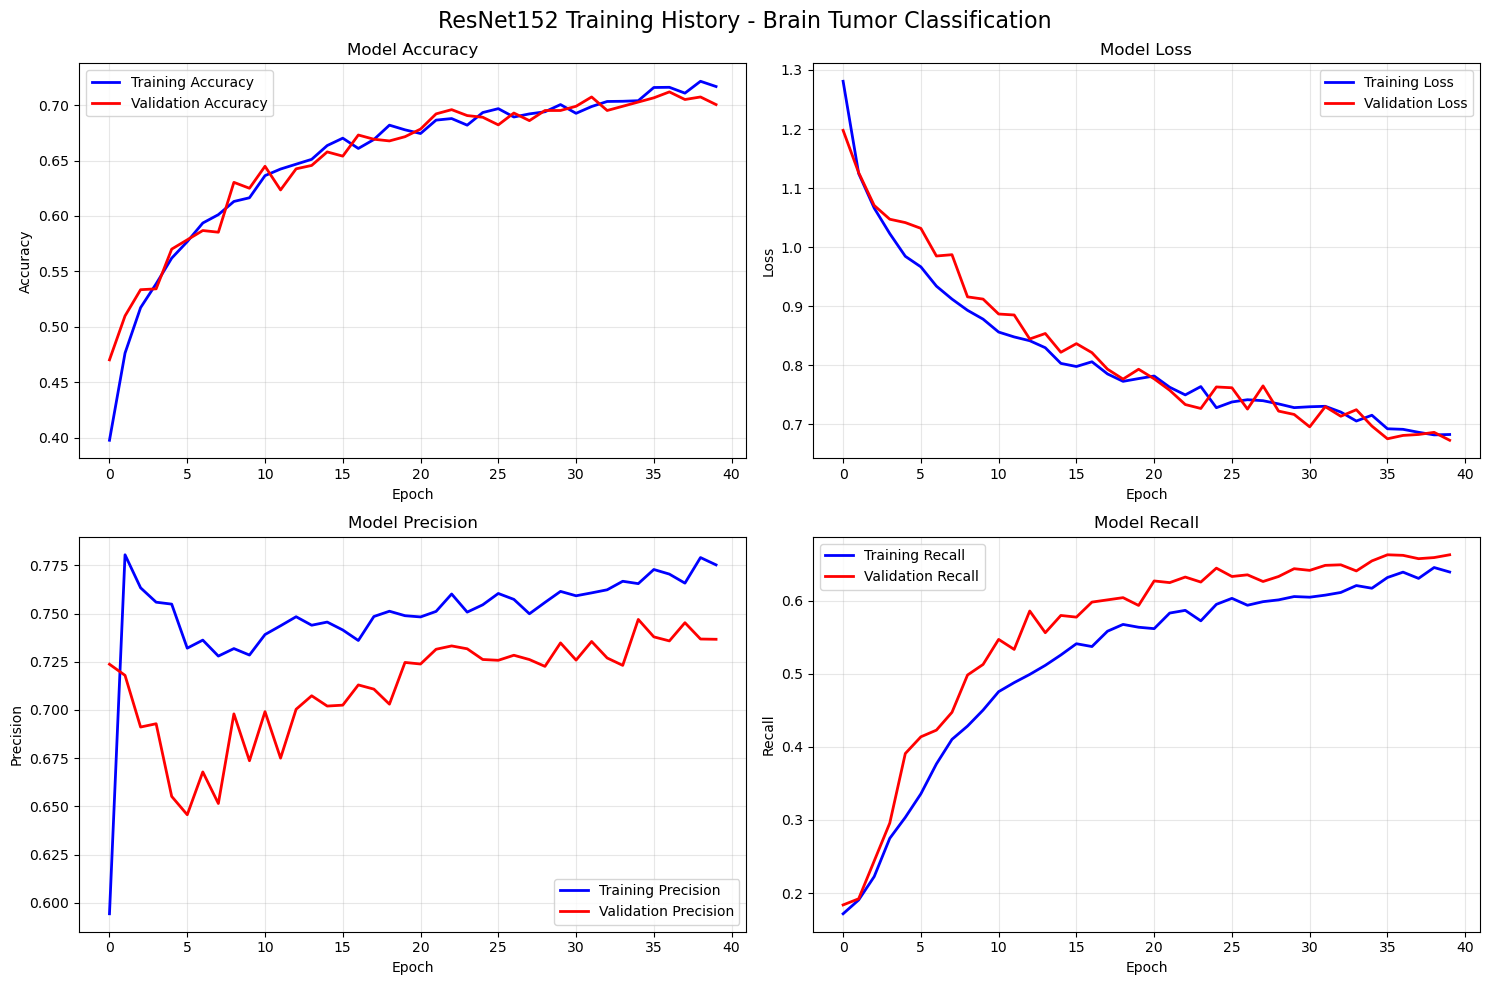


=== FINAL TRAINING RESULTS ===
Final Training Accuracy: 0.7167
Final Validation Accuracy: 0.7005
Final Training Loss: 0.6829
Final Validation Loss: 0.6731


In [11]:
def plot_training_history(history, save_path='models/resnet152_training_history.png'):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('ResNet152 Training History - Brain Tumor Classification', fontsize=16)
    
    axes[0, 0].plot(history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].plot(history.history['precision'], 'b-', label='Training Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], 'r-', label='Validation Precision', linewidth=2)
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(history.history['recall'], 'b-', label='Training Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], 'r-', label='Validation Recall', linewidth=2)
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\n=== FINAL TRAINING RESULTS ===")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

In [12]:
best_model = tf.keras.models.load_model('models/best_resnet152_brain_tumor.h5')
print("Best ResNet152 model loaded!")

print("Making predictions on test set...")
val_generator.reset()
predictions = best_model.predict(val_generator, steps=validation_steps, verbose=1)

true_labels = val_generator.classes[:len(predictions)]
predicted_labels = np.argmax(predictions, axis=1)

test_accuracy = np.mean(predicted_labels == true_labels)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

class_names_ordered = [list(val_generator.class_indices.keys())[i] for i in range(NUM_CLASSES)]
report = classification_report(true_labels, predicted_labels, 
                             target_names=class_names_ordered, 
                             output_dict=True)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels, target_names=class_names_ordered))

Best ResNet152 model loaded!
Making predictions on test set...
82/82 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step

Test Accuracy: 0.7119 (71.19%)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      glioma       0.78      0.50      0.61       301
  meningioma       0.55      0.46      0.50       306
     notumor       0.79      0.89      0.84       405
   pituitary       0.70      0.94      0.80       300

    accuracy                           0.71      1312
   macro avg       0.70      0.70      0.69      1312
weighted avg       0.71      0.71      0.70      1312



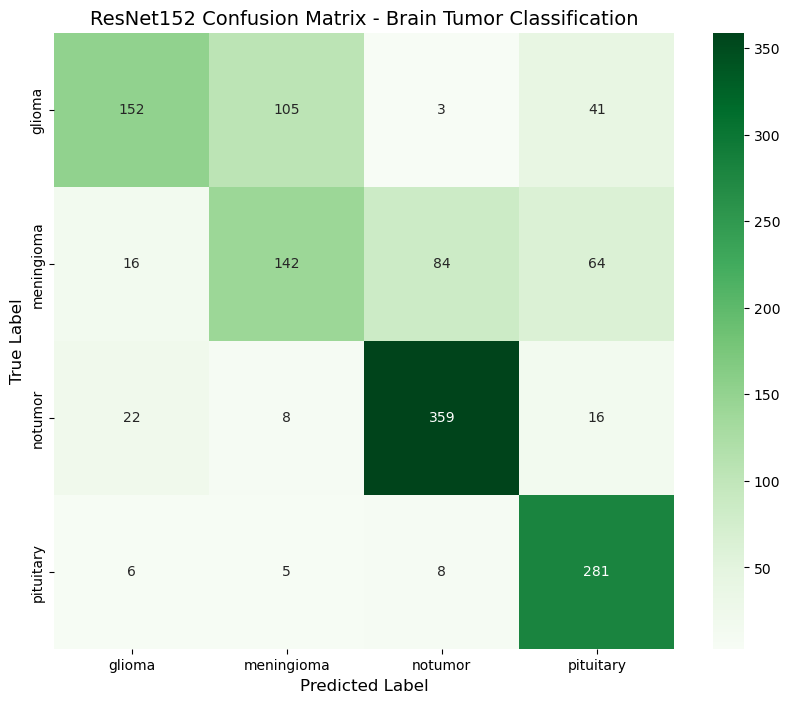


=== PER-CLASS PERFORMANCE ===
glioma:
  Accuracy: 0.505
  Precision: 0.776
  Recall: 0.505
  F1-Score: 0.612

meningioma:
  Accuracy: 0.464
  Precision: 0.546
  Recall: 0.464
  F1-Score: 0.502

notumor:
  Accuracy: 0.886
  Precision: 0.791
  Recall: 0.886
  F1-Score: 0.836

pituitary:
  Accuracy: 0.937
  Precision: 0.699
  Recall: 0.937
  F1-Score: 0.801



In [13]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names_ordered, 
            yticklabels=class_names_ordered)
plt.title('ResNet152 Confusion Matrix - Brain Tumor Classification', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.savefig('models/resnet152_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== PER-CLASS PERFORMANCE ===")
for i, class_name in enumerate(class_names_ordered):
    class_accuracy = cm[i, i] / cm[i].sum()
    precision = report[class_name]['precision']
    recall = report[class_name]['recall']
    f1_score = report[class_name]['f1-score']
    
    print(f"{class_name}:")
    print(f"  Accuracy: {class_accuracy:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1-Score: {f1_score:.3f}")
    print()

In [15]:
import json

summary = {
    'model': 'ResNet152',
    'dataset_size': {
        'training': train_generator.samples,
        'validation': val_generator.samples,
        'total': train_generator.samples + val_generator.samples
    },
    'classes': class_names_ordered,
    'training_config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'image_size': IMG_SIZE
    },
    'final_results': {
        'training_accuracy': final_train_acc,
        'validation_accuracy': final_val_acc,
        'test_accuracy': test_accuracy,
        'training_loss': final_train_loss,
        'validation_loss': final_val_loss
    }
}

with open('models/resnet152_training_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("=== RESNET152 TRAINING SUMMARY ===")
print(f"Model: ResNet152")
print(f"Total training images: {summary['dataset_size']['training']}")
print(f"Total validation images: {summary['dataset_size']['validation']}")
print(f"Classes: {', '.join(summary['classes'])}")
print(f"Training epochs: {EPOCHS}")
print(f"Final test accuracy: {test_accuracy:.4f}")
print(f"\nAll results saved to 'models/' directory")
print(" Best model: best_resnet152_brain_tumor.h5")
print(" Training plots: resnet152_training_history.png")
print(" Confusion matrix: resnet152_confusion_matrix.png")
print(" Training summary: resnet152_training_summary.json")

print("\n ResNet152 training completed successfully!")

=== RESNET152 TRAINING SUMMARY ===
Model: ResNet152
Total training images: 5712
Total validation images: 1312
Classes: glioma, meningioma, notumor, pituitary
Training epochs: 40
Final test accuracy: 0.7119

All results saved to 'models/' directory
 Best model: best_resnet152_brain_tumor.h5
 Training plots: resnet152_training_history.png
 Confusion matrix: resnet152_confusion_matrix.png
 Training summary: resnet152_training_summary.json

 ResNet152 training completed successfully!
